# Métodos de Monte Carlo - pêndulo invertido

#### Prof. Armando Alves Neto - Introdução ao Aprendizado por Reforço - PPGEE/UFMG

<div style="text-align: center;">
    <img src="cart_pole.gif" width="400">
</div>

Objetivo: usar o controle de Monte Carlo de primeira visita para estimar uma política $\pi \approx \pi_*$ que controle um pêndulo invertido. Aqui, a garantia de "*exploring starts*" é fraca.

## Características do pêndulo:

### Espaço de observações

| Número | Observação | Min | Max |
| :-: | :- | :-: | :-: |
| 0	| Posição do carrinho | -4.8 | 4.8|
| 1	| Velocidade do carrinho | -$\infty$ | $\infty$|
| 2	| Ângulo do pêndulo | -0.42 rad ($\approx$ -24°)	| 0.42 rad ($\approx$ 24°)|
| 3	| Velocidade angular do pêndulo	| -$\infty$ | $\infty$ |

### Espaço de ações
| Número | Ação |
| :-: | :- |
| 0	| Carrinho para a esquerda |
| 1	| Carrinho para a direita |

### Função de recompensa

- Devolve +1 para cada passo antes do pêndulo cair.
- Episódio termina quando o ângulo do pêndulo excede ±12°, ou quando a posição do carrinho é maior que ±2.4.
- Máximo de 500 passos.

Importando bilbiotecas. A biblioteca gym emula ambientes para aprendizado por reforço (no caso, o pêndulo).

In [1]:
import gymnasium as gym
import numpy as np
from functools import partial
from IPython.display import clear_output
import matplotlib.pyplot as plt

Criando uma classe para gerenciar as listas de *retornos(s,a)* para todos os estados e ações.

In [2]:
class Returns:
    ##########################################
    def __init__(self):
        self.r = []
    ##########################################
    def append(self, G):
        self.r.append(G) 
    ##########################################
    # média corrente dos retornos(s)
    def get_average(self):
        return np.mean(self.r) if self.r else 0.0

Criando a classe do Monte Carlo tabular. Nesse exemplo, vamos usar o pêndulo: ```gym.make('CartPole-v1')```.

In [3]:
class TabularMC():
    ##########################################
    def __init__(self, parameters):

        # conta episodios
        self.episode = 0

        # cria o ambiente (pendulo invertido)
        env_name = 'CartPole-v1'
        if parameters['render']:
            self.env = gym.make(env_name, render_mode='human')
        else:
            self.env = gym.make(env_name)
        num_states = [4, 8, 8, 8]
        lower_bounds = [-4.8, -3.0, -0.418, -2.0]
        upper_bounds = [ 4.8,  3.0,  0.418,  2.0]

        # converte estados continuos em discretos
        self.get_state = partial(self.obs_to_state, num_states, lower_bounds, upper_bounds)

        # tamanho dos espacos de estados e acoes
        self.num_states = np.prod(np.array(num_states))
        self.num_actions = self.env.action_space.n

        # parametros de aprendizado
        self.gamma = parameters['gamma']

        # reseta tudo
        self.reset()

        # eh first-visit ou every-visit?
        self.method = parameters['method']

    ##########################################
    # reseta a funcao acao-valor
    def reset(self):
        # Q(s,a)
        self.Q = np.zeros((self.num_states, self.num_actions))

        # Retornos(s,a)
        self.returns = [ [ Returns() for i in range(self.num_actions) ] for j in range(self.num_states) ]

    ##########################################
    # retorna a politica corrente
    def curr_policy(self, copy=False):
        if copy:
            return partial(self.max_policy, np.copy(self.Q))
        else:
            return partial(self.max_policy, self.Q)

    ##########################################
    # converte estados continuos em discretos
    def obs_to_state(self, num_states, lower_bounds, upper_bounds, obs):
        state_idx = []
        for ob, lower, upper, num in zip(obs, lower_bounds, upper_bounds, num_states):
            state_idx.append(self.discretize_val(ob, lower, upper, num))
        return np.ravel_multi_index(state_idx, num_states)

    ##########################################
    # discretiza um valor
    def discretize_val(self, val, min_val, max_val, num_states):
        state = int(num_states * (val - min_val) / (max_val - min_val))
        return np.clip(state, 0, num_states - 1)
        

Usando $\pi(s)$ para gerar um episódio: $S_0$, $A_0$, $R_1$, $\ldots$, $S_{T-1}$, $A_{T-1}$, $R_T$.

In [4]:
class TabularMC(TabularMC):
    ##########################################
    # simula um episodio até o fim seguindo a politica corrente
    def one_episode(self):
        
        # inicia o ambiente (começa aleatoriamente)
        obs, _ = self.env.reset(options={"low": -0.1, "high": 0.1})
        # acao inicial
        A = None

        # listas da trajetoria S_{T-1}, A_{T-1}, R_{T}, ....
        rewards, actions, states = ([] for i in range(3))

        while True:
            # gera estados baseado na observacao
            S = self.get_state(obs)

            # escolhe acao
            if A is None:
                # "explorig starts"
                A = self.env.action_space.sample()
            else:
                # \pi(s)
                A = self.policy(S)

            # passo de interacao com o ambiente
            obs, R, done, truncated, info = self.env.step(A)

            # Salva S_{T-1}, A_{T-1}, R_{T}, ....
            actions.append(A)
            states.append(S)
            rewards.append(R)

            # chegou a um estado terminal?
            if done or truncated: 
                break

        return [states, actions, rewards]

Computa a função ação-valor $Q(S_t, A_t) \gets \textrm{média}(Retornos(S_t, A_t))$

In [5]:
class TabularMC(TabularMC):
    ##########################################
    def Iterate(self):

        # novo episodio
        self.episode += 1

        # pega a politica corrente (on-policy)
        self.policy = self.curr_policy()

        # gera um episodio seguindo a politica corrente
        [states, actions, rewards] = self.one_episode()

        G = 0.0
        
        # processa experiencia (de tras para frente)
        for t in reversed(range(len(states))):
            
            # Get S_{T}, R_{T+1}
            s = states[t]
            a = actions[t]
            r = rewards[t]
            
            # first-visit?
            if self.method == 'first_visit':
                if (s, a) in list(zip(states[0:t], actions[0:t])):
                    continue

            # atualiza Q(s,a)
            G = self.gamma*G + r
            self.returns[s][a].append(G)
            
            # Q(S_t, A_t) \gets média(Retornos(S_t, A_t))
            self.Q[s, a] = self.returns[s][a].get_average()

        return np.sum(np.array(rewards))

Probabilidade de escolha de uma ação $a$ baseada na política gulosa:
$$
\pi(S_t) \gets \arg\max_{a} Q(S_t,a)
$$

In [6]:
class TabularMC(TabularMC):
    ##########################################
    # acao com valor maximo
    def max_policy(self, Q, state):
        return Q[state, :].argmax()

Programa principal:

- episodes: número de episódios
- max_steps: número máximo de passos no episódio
- gamma: fator de desconto
- method: *first-visit* ou *every-visit*
- render: renderiza animação

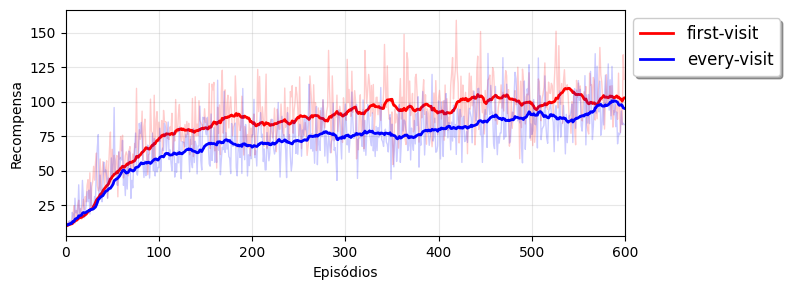

In [7]:
if __name__ == '__main__':
    
    plt.ion()
    plt.rcParams['figure.figsize'] = (8,3)
    plt.figure(1)
    
    # parametros
    parameters = {'episodes'  : 600,
                  'gamma'     : 0.99,
                  'method'    : '', # 'first-visit' ou 'every-visit'
                  'render'    : False,
                  'nagents'   : 10,
                 }
    
    # Cria Monte-Carlo tabular
    parameters['method'] = 'first-visit'
    mcs_first = [TabularMC(parameters) for _ in range(parameters['nagents'])]
    parameters['method'] = 'every-visit'
    mcs_every = [TabularMC(parameters) for _ in range(parameters['nagents'])]

    # historico dos recompensas
    rewards_f = []
    rewards_e = []
    avg_f = []
    avg_e = []
    
    # loop principal
    for i in range(parameters['episodes']):
        
        # roda um episodio e armazena a média de todos os agentes
        rewards_f.append(np.mean( [mc.Iterate() for mc in mcs_first] ))
        rewards_e.append(np.mean( [mc.Iterate() for mc in mcs_every] ))
        
        # reward medio
        avg_f.append(np.mean(rewards_f[-30:]))
        avg_e.append(np.mean(rewards_e[-30:]))
        
        # plot
        clear_output(wait=True)
        plt.clf()
        plt.plot(rewards_f, 'r', alpha=0.2, linewidth=1)
        plt.plot(avg_f, 'r', linewidth=2, label='first-visit')
        #
        plt.plot(rewards_e, 'b', alpha=0.2, linewidth=1)
        plt.plot(avg_e, 'b', linewidth=2, label='every-visit')
        #
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fancybox=True, shadow=True, fontsize=12, facecolor='w')
        plt.xlabel('Episódios')
        plt.ylabel('Recompensa')
        plt.xlim([0, parameters['episodes']])
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.gcf().patch.set_alpha(0)
        plt.show()
        plt.pause(.1)